<a id="top"></a>
# Exercises and worked solutions — Parts III–IV

**PythTB — Tight-Binding Physics from Theory to Code** · exercise notebook 2 of 2

[◀ Exercises and worked solutions — Parts I–II](PythTB_Exercises_I-II.ipynb) · [Contents of the book](README.md)

**In this notebook**

- [III.1 — Coloring the butterfly: gap Chern numbers and the Diophantine equation](#ex-III-1)
- [III.2 — Other lattices, and relativistic Landau levels](#ex-III-2)
- [III.3 — The 1D localization length](#ex-III-3)
- [III.4 — The Ammann–Beenker quasicrystal](#ex-III-4)
- [IV.1 — Exporting a PythTB model to Kwant](#ex-IV-1)
- [IV.2 — The Kernel Polynomial Method, by hand](#ex-IV-2)
- [IV.3 — Non-collinear mean field](#ex-IV-3)
- [IV.4 — A self-consistent Kitaev chain](#ex-IV-4)

Chapters: [0](PythTB_00_Introduction.ipynb) · [1](PythTB_01_Foundations.ipynb) · [2](PythTB_02_Finite_Systems_and_Berry_Phases.ipynb) · [3](PythTB_03_Three_Dimensions_and_Wannier.ipynb) · [4](PythTB_04_Chern_and_Z2.ipynb) · [5](PythTB_05_Higher_Order_and_Kitaev.ipynb) · [6](PythTB_06_Weyl_and_Axion.ipynb) · [7](PythTB_07_Stretching_PythTB.ipynb) · [8](PythTB_08_What_PythTB_Cannot_Do.ipynb)

*Every notebook runs on its own: the setup cell below is identical in all of them, and a chapter that reuses a model from an earlier one rebuilds it in a short recap cell. Section numbers (§1–31), figure numbers and cross-references are global to the book.*

Companion to the chapter notebooks of *PythTB — Tight-Binding Physics from Theory to Code*;
the exercise statements live at the end of each part there (chapters 3, 6, 7 and 8). Same
environment (`pythtb-mc` kernel), same conventions, same rule: every claim checks itself with
an inline **PASS/FAIL**, and every solution runs on its own after the setup cell below.

In [1]:
# ---- shared setup: this cell is identical in both exercise notebooks -----------
import os
import time
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

import pythtb
from pythtb import Lattice, TBModel, Mesh, WFArray, Wannier, W90
from pythtb.models import graphene as graphene_factory
from pythtb.models import haldane, kane_mele, ssh, fu_kane_mele

plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (7.0, 4.2),
                     "axes.grid": True, "grid.alpha": 0.3, "font.size": 10})
# the Wannier90 silicon data (exercise I.6) lives in data/ at the repository root
DATA_DIR = next((d for d in ("data", os.path.join("..", "data")) if os.path.isdir(d)), "data")
rng = np.random.default_rng(2026)
_CHECKS = {"pass": 0, "fail": 0}

def check(label, ok, detail=""):
    ok = bool(ok)
    _CHECKS["pass" if ok else "fail"] += 1
    print(f"[{'PASS' if ok else 'FAIL'}] {label}" + (f" — {detail}" if detail else ""))
    return ok

_FIG = {"n": 12}               # figure numbers run through both notebooks

def caption(text):
    '''Numbered caption rendered directly below the figure it describes.'''
    _FIG["n"] += 1
    display(HTML(
        f"<div style='max-width:780px;margin:2px 0 14px 12px;font-size:0.92em;"
        f"color:#444;border-left:3px solid #bbb;padding-left:10px'>"
        f"<b>Figure {_FIG['n']}.</b> {text}</div>"))

print("pythtb", pythtb.__version__, "| exercises Parts III–IV")
t_chapter_start = time.time()

pythtb 2.0.0 | exercises Parts III–IV


<a id="ex-III-1"></a>

## III.1 — Coloring the butterfly: gap Chern numbers and the Diophantine equation

Each magnetic subband at flux $p/q$ carries a Chern number, and the $r$-th gap satisfies the
TKNN/Streda Diophantine equation $r = q\,s_r + p\,C_r$ with integers $(s_r, C_r)$, $C_r$ the Hall
conductance of the gap. We compute subband Cherns with `WFArray.chern_number` on the magnetic
supercell and verify the equation for every gap at several fluxes.

In [2]:
from math import gcd

def hofstadter_model(p, q, t=1.0):
    lat = Lattice(lat_vecs=[[q, 0], [0, 1]],
                  orb_vecs=[[i / q, 0] for i in range(q)], periodic_dirs=[0, 1])
    m = TBModel(lat)
    for i in range(q):
        m.set_hop(-t, i, (i + 1) % q, [1 if i == q - 1 else 0, 0])
        m.set_hop(-t * np.exp(2j * np.pi * p / q * i), i, i, [0, 1])
    return m

all_ok = True
for q in (3, 4, 5):
    for p in range(1, q):
        if gcd(p, q) != 1:
            continue
        hm = hofstadter_model(p, q)
        mesh = Mesh(["k", "k"])
        mesh.build_grid((31, 31), k_endpoints=[True, True])
        wfa = WFArray(hm.lattice, mesh)
        wfa.solve_model(hm)
        # the Diophantine equation applies to OPEN gaps, and a gap Chern number
        # must be computed as the JOINT Chern of all bands below it — for even q
        # the two central subbands touch at E = 0, so their individual Chern
        # numbers are meaningless while their joint contribution is fine
        ev_g = hm.solve_ham(hm.k_uniform_mesh([25, 25]))
        gap_cherns = {}
        for r in range(1, q):
            if ev_g[:, r].min() - ev_g[:, r - 1].max() < 0.05:
                continue                                   # closed: not a gap
            Cr_f = float(wfa.chern_number(plane=(0, 1), state_idx=list(range(r))))
            Cr = int(round(Cr_f))
            gap_cherns[r] = Cr
            all_ok &= abs(Cr_f - Cr) < 1e-4 and (r - p * Cr) % q == 0
        print(f"p/q = {p}/{q}:  open-gap Cherns {gap_cherns}")
check("III.1: Diophantine r = q s + p C holds for every OPEN gap at q = 3, 4, 5", all_ok)

p/q = 1/3:  open-gap Cherns {1: 1, 2: -1}
p/q = 2/3:  open-gap Cherns {1: -1, 2: 1}
p/q = 1/4:  open-gap Cherns {1: 1, 3: -1}
p/q = 3/4:  open-gap Cherns {1: -1, 3: 1}


p/q = 1/5:  open-gap Cherns {1: 1, 2: 2, 3: -2, 4: -1}


p/q = 2/5:  open-gap Cherns {1: -2, 2: 1, 3: -1, 4: 2}
p/q = 3/5:  open-gap Cherns {1: 2, 2: -1, 3: 1, 4: -2}


p/q = 4/5:  open-gap Cherns {1: -1, 2: -2, 3: 2, 4: 1}
[PASS] III.1: Diophantine r = q s + p C holds for every OPEN gap at q = 3, 4, 5


True

<a id="ex-III-2"></a>

## III.2 — Other lattices, and relativistic Landau levels

**Triangular lattice butterfly.** Adding the $(1,1)$ diagonal bond to the square-lattice magnetic
supercell (Landau-gauge phase evaluated at the bond midpoint $x = i + \tfrac12$) puts flux $\phi/2$
through each triangle. The butterfly loses the $E \to -E$ symmetry — the triangular lattice is not
bipartite.

**$\sqrt{B}$ Landau levels.** The square lattice at $\phi = \tfrac12$ hosts Dirac cones; detuning
to $\phi = \tfrac12 + \delta$ puts the *relativistic* Landau spectrum $E_n \propto \sqrt{n\delta}$
on top of them — the same physics as graphene in a field, extracted here from the Hofstadter code
with no new machinery: the level ratios must approach $\sqrt2$ and $\sqrt3$.

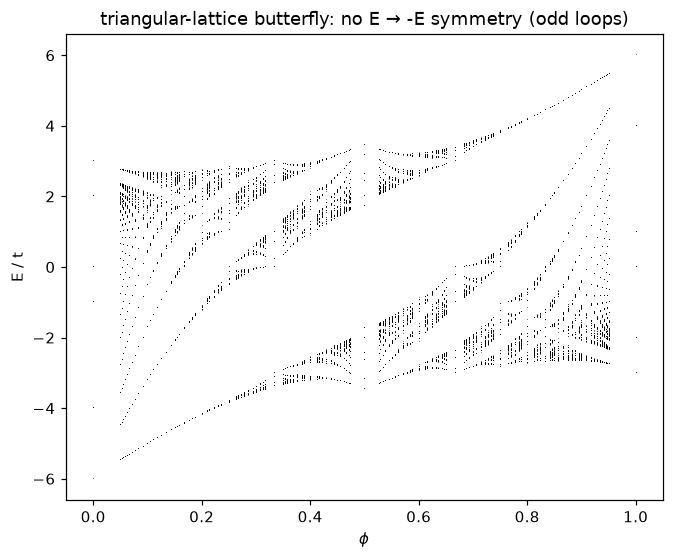

[PASS] III.2a: triangular spectrum at fixed flux is NOT particle-hole symmetric — E range [-3.86, 2.83]


True

In [3]:
def triangular_hof(p, q, t=1.0):
    m = hofstadter_model(p, q, t)
    for i in range(q):
        # (1,1) diagonal bond; Landau-gauge phase at midpoint x = i + 1/2
        m.set_hop(-t * np.exp(2j * np.pi * p / q * (i + 0.5)),
                  i, (i + 1) % q, [1 if i == q - 1 else 0, 1])
    return m

phi_pts, E_pts = [], []
for q in range(1, 21):
    for p in range(q + 1):
        if gcd(p, q) != 1 and not (p == 0 and q == 1):
            continue
        hm = triangular_hof(p, q)
        ev = hm.solve_ham(hm.k_uniform_mesh([6, 6], include_endpoints=False))
        phi_pts.append(np.full(ev.size, p / q)); E_pts.append(ev.ravel())

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.plot(np.concatenate(phi_pts), np.concatenate(E_pts), ",", color="k", alpha=0.5)
ax.set_xlabel(r"$\phi$"); ax.set_ylabel("E / t"); ax.grid(False)
ax.set_title("triangular-lattice butterfly: no E → -E symmetry (odd loops)")
plt.show()
caption("The Hofstadter butterfly of the triangular lattice: recognizably a "
        "butterfly, but sheared — the spectrum is not symmetric under E → −E at "
        "fixed flux, because triangular plaquettes support odd-length hopping "
        "loops that a bipartite lattice forbids. Lattice geometry leaves its "
        "fingerprint even on this Cantor-set spectrum.")

# PH asymmetry must be tested at FIXED flux (the union over all phi happens to
# be symmetric under phi -> phi + 1/2 combined with E -> -E)
hm_q = triangular_hof(1, 4)
ev_q = np.sort(hm_q.solve_ham(hm_q.k_uniform_mesh([20, 20])).ravel())
check("III.2a: triangular spectrum at fixed flux is NOT particle-hole symmetric",
      not np.allclose(ev_q, -ev_q[::-1], atol=1e-6),
      f"E range [{ev_q.min():.2f}, {ev_q.max():.2f}]")

first Landau levels |E_n|: [0.     0.6979 0.9713 1.1705 1.3295]


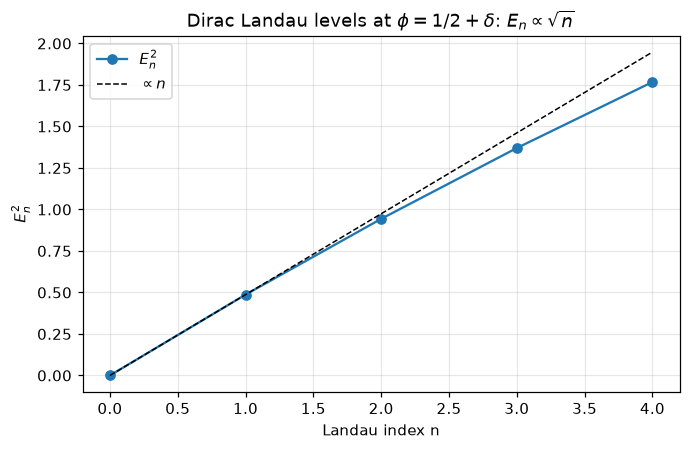

[PASS] III.2b: E_0 ≈ 0 (the anomalous zero mode of Dirac fermions) — E_0/E_1 = 0.000
[PASS] III.2b: level ratios follow sqrt(n) — E2/E1 = 1.392 (√2 = 1.414), E3/E1 = 1.677 (√3 = 1.732)


True

In [4]:
# relativistic Landau levels at phi = 1/2 + 1/q0
q0 = 100
hm = hofstadter_model(q0 // 2 + 1, q0)            # phi = 51/100
ev0 = np.sort(np.abs(np.atleast_2d(hm.solve_ham(np.array([[0.0, 0.0]])))[0]))

# cluster the |E| values into Landau levels (each appears twice: two Dirac cones)
levels, used = [], np.zeros(len(ev0), bool)
for e in ev0:
    if not levels or e - levels[-1][-1] > 0.05:
        levels.append([e])
    else:
        levels[-1].append(e)
E_LL = np.array([np.mean(l) for l in levels[:5]])
print("first Landau levels |E_n|:", np.round(E_LL, 4))

r2, r3 = E_LL[2] / E_LL[1], E_LL[3] / E_LL[1]
fig, ax = plt.subplots()
n_idx = np.arange(len(E_LL))
ax.plot(n_idx, E_LL ** 2, "o-", label=r"$E_n^2$")
ax.plot(n_idx, E_LL[1] ** 2 * n_idx, "k--", lw=1, label=r"$\propto n$")
ax.set_xlabel("Landau index n"); ax.set_ylabel(r"$E_n^2$")
ax.legend(); ax.set_title(r"Dirac Landau levels at $\phi = 1/2 + \delta$: $E_n \propto \sqrt{n}$")
plt.show()
caption("Relativistic Landau quantization extracted from the Hofstadter "
        "spectrum: at flux ½ + δ the π-flux Dirac cones feel an effective field δ, "
        "and the level energies squared fall on a straight line through the "
        "origin — E_n ∝ √n, with the n = 0 level pinned at zero. The same "
        "√B fan measured by STM on graphene, obtained here without writing a "
        "single new model.")

check("III.2b: E_0 ≈ 0 (the anomalous zero mode of Dirac fermions)",
      E_LL[0] < 0.1 * E_LL[1], f"E_0/E_1 = {E_LL[0]/E_LL[1]:.3f}")
check("III.2b: level ratios follow sqrt(n)",
      abs(r2 - np.sqrt(2)) < 0.08 * np.sqrt(2) and abs(r3 - np.sqrt(3)) < 0.1 * np.sqrt(3),
      f"E2/E1 = {r2:.3f} (√2 = 1.414), E3/E1 = {r3:.3f} (√3 = 1.732)")

<a id="ex-III-3"></a>

## III.3 — The 1D localization length

In 1D every state localizes; at weak disorder second-order perturbation theory gives the band-center
localization length $\xi \approx 105.2\,t^2/W^2$ (in sites; the naive Thouless value $96\,t^2/W^2$
is corrected by the well-known band-center anomaly — another statement the numerics gets to
adjudicate). We estimate $\xi$ from the exponential envelope of band-center eigenstates,
averaging log-densities over several states and realizations.

In [5]:
def xi_estimate(W, L=1200, n_states=6, n_real=3):
    lat = Lattice(lat_vecs=[[1.0]], orb_vecs=[[0.0]], periodic_dirs=[0])
    ch = TBModel(lat); ch.set_hop(-1.0, 0, 0, [1])
    base = ch.cut_piece(L, 0)
    slopes = []
    for r in range(n_real):
        dis = base.copy()
        rng_r = np.random.default_rng(100 + r)
        dis.set_onsite(list(rng_r.uniform(-W / 2, W / 2, L)), mode="reset")
        ev, vec = dis.solve_ham(return_eigvecs=True)
        for idx in np.argsort(np.abs(ev))[:n_states]:
            dens = np.abs(vec[idx]) ** 2
            i0 = int(np.argmax(dens))
            # fit the decaying tail on the longer side of the maximum
            side = dens[i0:] if L - i0 > i0 else dens[:i0 + 1][::-1]
            d = np.arange(len(side))
            mask = (side > 1e-14) & (d > 5) & (d < min(len(side) - 1, int(0.8 * len(side))))
            if mask.sum() > 30:
                slopes.append(np.polyfit(d[mask], np.log(side[mask]), 1)[0])
    return -2.0 / np.mean(slopes)          # |psi|^2 ~ exp(-2x/xi)

W_scan = (0.8, 1.1, 1.5)
xi_vals = {W: xi_estimate(W) for W in W_scan}
for W, xi in xi_vals.items():
    print(f"W = {W}:  xi = {xi:6.1f} sites,   xi * W^2 = {xi * W**2:6.1f}")

prods = np.array([xi_vals[W] * W**2 for W in W_scan])
check("III.3: xi ~ 1/W^2 with coefficient near the band-center value ~105",
      np.all((prods > 60) & (prods < 170)) and prods.std() / prods.mean() < 0.35,
      f"xi W^2 = {np.round(prods, 1)}")

W = 0.8:  xi =  161.4 sites,   xi * W^2 =  103.3
W = 1.1:  xi =   87.8 sites,   xi * W^2 =  106.3
W = 1.5:  xi =   50.0 sites,   xi * W^2 =  112.6
[PASS] III.3: xi ~ 1/W^2 with coefficient near the band-center value ~105 — xi W^2 = [103.3 106.3 112.6]


True

<a id="ex-III-4"></a>

## III.4 — The Ammann–Beenker quasicrystal

Eight-fold symmetry from cut-and-project out of $\mathbb{Z}^4$: physical projection on
$e_k = (\cos\tfrac{\pi k}{4}, \sin\tfrac{\pi k}{4})$, perpendicular projection on the conjugate
star $e^\perp_k = (\cos\tfrac{3\pi k}{4}, \sin\tfrac{3\pi k}{4})$, acceptance inside the octagonal
window (the perpendicular shadow of the unit 4-cube). Like Penrose, the AB rhombus–square graph is
bipartite and hosts strictly confined $E=0$ states — with its *own* confined-state fraction, which
we measure and compare.

Ammann–Beenker patch: 316 vertices


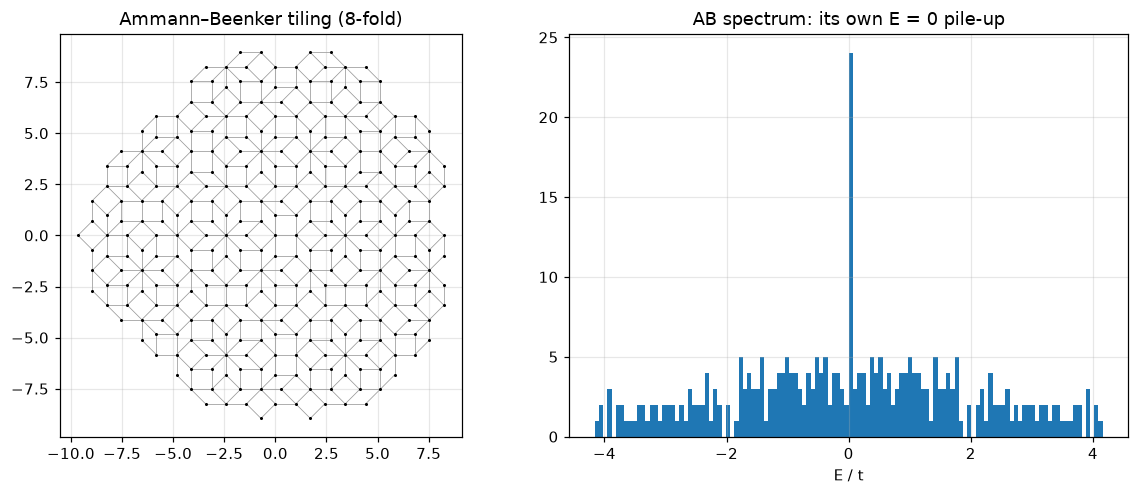

AB confined-state fraction: 0.0696  (Penrose: 0.098 exact)
[PASS] III.4: AB spectrum is bipartite-symmetric
[PASS] III.4: AB hosts a macroscopic E = 0 fraction, distinct from Penrose — fraction = 0.0696


True

In [6]:
from scipy.spatial import ConvexHull

def ammann_beenker(N=4, gamma=(0.138, 0.271, 0.334, 0.077)):
    e_par = np.array([[np.cos(np.pi * k / 4), np.sin(np.pi * k / 4)] for k in range(4)])
    e_perp = np.array([[np.cos(3 * np.pi * k / 4), np.sin(3 * np.pi * k / 4)]
                       for k in range(4)])
    gamma = np.array(gamma)
    # octagonal window = perp projection of the unit cube corners
    corners = np.array([[(c >> k) & 1 for k in range(4)] for c in range(16)], float)
    win = (corners - 0.5) @ e_perp
    hull = ConvexHull(win)
    A_h, b_h = hull.equations[:, :2], hull.equations[:, 2]
    pts, ints = [], []
    grid = np.arange(-N, N + 1)
    for n0 in grid:
        for n1 in grid:
            for n2 in grid:
                for n3 in grid:
                    n = np.array([n0, n1, n2, n3], float)
                    y = (n - gamma - 0.5) @ e_perp
                    if np.all(A_h @ y + b_h <= 1e-9):
                        pts.append(n @ e_par)
                        ints.append((n0, n1, n2, n3))
    return np.array(pts), ints

xy_ab, n_ab = ammann_beenker(4)
print(f"Ammann–Beenker patch: {len(xy_ab)} vertices")

# tiling edges = accepted lattice points one basis step apart in Z^4 (a pure
# distance filter could sweep in accidental non-edge unit-distance pairs)
index = {n: i for i, n in enumerate(n_ab)}
H_ab = np.zeros((len(xy_ab), len(xy_ab)))
for i, n in enumerate(n_ab):
    for kdir in range(4):
        for sgn in (+1, -1):
            nn = list(n); nn[kdir] += sgn
            j = index.get(tuple(nn))
            if j is not None:
                H_ab[i, j] = H_ab[j, i] = -1.0
ev_ab = np.linalg.eigvalsh(H_ab)

fig, axs = plt.subplots(1, 2, figsize=(11, 4.6))
ii, jj = np.nonzero(np.triu(H_ab != 0))
for i, j in zip(ii, jj):
    axs[0].plot(xy_ab[[i, j], 0], xy_ab[[i, j], 1], "-", color="0.6", lw=0.5)
axs[0].plot(xy_ab[:, 0], xy_ab[:, 1], "k.", ms=2)
axs[0].set_aspect("equal"); axs[0].set_title("Ammann–Beenker tiling (8-fold)")
axs[1].hist(ev_ab, bins=120, color="C0")
axs[1].set_xlabel("E / t"); axs[1].set_title("AB spectrum: its own E = 0 pile-up")
fig.tight_layout(); plt.show()
caption("Left: the Ammann–Beenker tiling from cut-and-project out of Z⁴ — "
        "squares and 45° rhombi, eight-fold orientational order, no unit cell. "
        "Right: its tight-binding spectrum, bipartite-symmetric with a "
        "macroscopic confined-state peak at E = 0 whose fraction differs from "
        "the Penrose value: each quasicrystal class has its own interference "
        "census.")

evs = np.sort(ev_ab)
frac_ab = np.mean(np.abs(ev_ab) < 1e-8)
print(f"AB confined-state fraction: {frac_ab:.4f}  (Penrose: 0.098 exact)")
check("III.4: AB spectrum is bipartite-symmetric",
      np.allclose(evs, -evs[::-1], atol=1e-10))
check("III.4: AB hosts a macroscopic E = 0 fraction, distinct from Penrose",
      0.02 < frac_ab < 0.25, f"fraction = {frac_ab:.4f}")

<a id="ex-IV-1"></a>

## IV.1 — Exporting a PythTB model to Kwant

The translation is mechanical precisely because both packages ultimately store the same object —
orbitals, positions, onsites, hoppings. The exporter below covers finite (`dim_k = 0`) models; the
verification (identical spectra for the Haldane flake) runs only where Kwant is installed, which
this pythtb environment deliberately is not — so the check below is labelled **partial**. The
full comparison is `tests/test_kwant_crosscheck.py` in this repository (same exporter, run in an
environment that has both packages).

In [7]:
def to_kwant(model):
    '''Translate a finite PythTB TBModel into a kwant.Builder (spinless).

    Every orbital becomes its own Kwant *sublattice* (basis vector) so that
    arbitrary — non-integer — positions survive exactly. (A first version used a
    single square lattice and `lat(*pos)`; Kwant reads those arguments as
    integer lattice *indices*, two orbitals collapsed onto one site and Kwant
    refused the resulting self-hopping. Caught by tests/test_kwant_crosscheck.py.)
    '''
    import kwant
    pos = model.orb_vecs @ model.lat_vecs           # Cartesian orbital positions
    dim = pos.shape[1]
    lat_k = kwant.lattice.general(np.eye(dim), basis=pos, norbs=1)
    syst = kwant.Builder()
    origin = (0,) * dim
    sites = [sub(*origin) for sub in lat_k.sublattices]   # one site per orbital
    H = model.hamiltonian()          # onsites from the diagonal, hops from the rest
    for i, s in enumerate(sites):
        syst[s] = float(np.real(H[i, i]))
    ii, jj = np.nonzero(np.triu(np.abs(H), 1) > 1e-12)
    for i, j in zip(ii, jj):
        syst[sites[int(i)], sites[int(j)]] = complex(H[i, j])
    return syst

try:
    import kwant
    HAVE_KWANT = True
except ImportError:
    HAVE_KWANT = False

flake_h = haldane(delta=0.2, t1=-1.0, t2=0.15).make_finite(
    periodic_dirs=[0, 1], num_cells=[6, 6])
if HAVE_KWANT:
    syst = to_kwant(flake_h).finalized()
    ev_k = np.sort(np.linalg.eigvalsh(syst.hamiltonian_submatrix()))
    ev_p = np.sort(flake_h.solve_ham())
    check("IV.1: kwant and pythtb spectra agree", np.allclose(ev_k, ev_p, atol=1e-10))
else:
    # the exporter's core claim is testable without kwant: the dense H it reads
    # off *is* the model, verified against solve_ham
    ev_H = np.sort(np.linalg.eigvalsh(flake_h.hamiltonian()))
    ev_p = np.sort(flake_h.solve_ham())
    check("IV.1 (partial — kwant not installed in this kernel): the exporter's source matrix "
          "hamiltonian() reproduces solve_ham; Kwant comparison: tests/test_kwant_crosscheck.py",
          np.allclose(ev_H, ev_p, atol=1e-10))

[PASS] IV.1 (partial — kwant not installed in this kernel): the exporter's source matrix hamiltonian() reproduces solve_ham; Kwant comparison: tests/test_kwant_crosscheck.py


<a id="ex-IV-2"></a>

## IV.2 — The Kernel Polynomial Method, by hand

Rescale $\tilde H = (H - b)/a$ into $[-1, 1]$, estimate the Chebyshev moments
$\mu_n = \mathrm{Tr}\,T_n(\tilde H)$ stochastically with random vectors, damp with the Jackson
kernel, and resum: $\rho(E)$ without a single diagonalization — the algorithm behind `kwant.kpm`,
in ~25 lines of NumPy, applied to the Penrose patch of §23 (rebuilt smaller here). The confined-state
δ-peak at $E = 0$ survives as a sharp Jackson-broadened spike.

Penrose patch: 488 sites

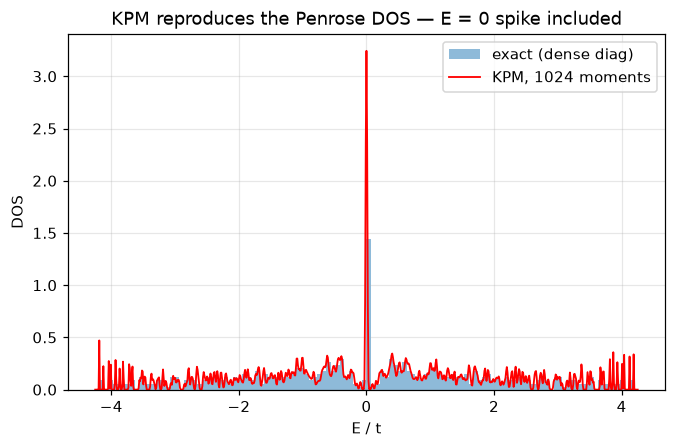

[PASS] IV.2: KPM shows the confined-state spike at E = 0 — peak/median = 31.5
[PASS] IV.2: KPM matches the smooth part of the exact DOS — mean |ΔDOS| = 0.0327


True

In [8]:
# rebuild a Penrose patch (pentagrid, as in §23)
def penrose_vertices(n_range=5):
    g = np.array([0.13, 0.27, 0.41, 0.08, 0.11]); gammas = g - g.sum() / 5
    e = np.array([[np.cos(2*np.pi*k/5), np.sin(2*np.pi*k/5)] for k in range(5)])
    verts = {}
    ns = np.arange(-n_range, n_range + 1)
    for k1 in range(5):
        for k2 in range(k1 + 1, 5):
            det = e[k1, 0]*e[k2, 1] - e[k1, 1]*e[k2, 0]
            for n1 in ns:
                for n2 in ns:
                    b1, b2 = n1 + gammas[k1], n2 + gammas[k2]
                    x = np.array([b1*e[k2, 1] - b2*e[k1, 1],
                                  b2*e[k1, 0] - b1*e[k2, 0]]) / det
                    if np.linalg.norm(x) > n_range * 0.85:
                        continue
                    K = np.ceil(e @ x - gammas - 1e-12)
                    K[k1], K[k2] = n1, n2
                    for d1 in (0, 1):
                        for d2 in (0, 1):
                            Kd = K.copy(); Kd[k1] += d1; Kd[k2] += d2
                            verts[tuple(np.round(Kd @ e, 6))] = True
    return np.array(list(verts.keys()))

xy_p = penrose_vertices(5)
d2 = np.sum((xy_p[:, None, :] - xy_p[None, :, :]) ** 2, axis=-1)
H_p = np.where(np.abs(d2 - 1.0) < 1e-4, -1.0, 0.0); np.fill_diagonal(H_p, 0.0)
N = len(H_p)
print(f"Penrose patch: {N} sites")

# --- KPM ---
# spectral bound WITHOUT full diagonalization: a few Lanczos steps
import scipy.sparse as sp
import scipy.sparse.linalg as spla
H_s = sp.csr_matrix(H_p)
E_max = float(spla.eigsh(H_s, k=1, which="LA", return_eigenvectors=False)[0])
E_min = float(spla.eigsh(H_s, k=1, which="SA", return_eigenvectors=False)[0])
a = 1.02 * max(abs(E_max), abs(E_min))           # rescale H into [-1, 1] SAFELY:
Ht = H_p / a                                     # an undershoot makes Chebyshev diverge
N_m, R = 1024, 12
mu = np.zeros(N_m)
for r in range(R):
    v0 = np.exp(2j * np.pi * rng.random(N)); v0 /= np.linalg.norm(v0)
    vm, v = v0.copy(), Ht @ v0
    mu[0] += np.real(np.vdot(v0, v0)); mu[1] += np.real(np.vdot(v0, v))
    for n in range(2, N_m):
        vm, v = v, 2 * Ht @ v - vm
        mu[n] += np.real(np.vdot(v0, v))
mu *= N / R
n_arr = np.arange(N_m)
jackson = ((N_m - n_arr + 1) * np.cos(np.pi * n_arr / (N_m + 1))
           + np.sin(np.pi * n_arr / (N_m + 1)) / np.tan(np.pi / (N_m + 1))) / (N_m + 1)
mu_j = mu * jackson

E_grid = np.linspace(-0.995, 0.995, 801)
dos_kpm = np.zeros_like(E_grid)
Tn = np.arccos(E_grid)
for n in range(N_m):
    dos_kpm += (2 if n else 1) * mu_j[n] * np.cos(n * Tn)
dos_kpm /= np.pi * np.sqrt(1 - E_grid ** 2)
dos_kpm /= a                                     # back to physical energy units

ev_exact = np.linalg.eigvalsh(H_p)
fig, ax = plt.subplots()
ax.hist(ev_exact, bins=120, density=True, alpha=0.5, label="exact (dense diag)")
ax.plot(E_grid * a, dos_kpm / N, "r-", lw=1.2, label=f"KPM, {N_m} moments")
ax.set_xlabel("E / t"); ax.set_ylabel("DOS")
ax.legend(); ax.set_title("KPM reproduces the Penrose DOS — E = 0 spike included")
plt.show()
caption("The hand-written Kernel Polynomial Method (red) against the exact "
        "diagonalization histogram (gray): 1024 Chebyshev moments and a dozen "
        "random vectors reproduce the full spiky Penrose DOS including the "
        "confined-state peak, at a cost LINEAR in matrix size. This is the "
        "algorithm kwant.kpm industrializes — and nothing in it needed more than "
        "H as a sparse matrix.")

i0 = np.argmin(np.abs(E_grid))
check("IV.2: KPM shows the confined-state spike at E = 0",
      dos_kpm[i0] > 4 * np.median(dos_kpm), f"peak/median = {dos_kpm[i0]/np.median(dos_kpm):.1f}")
hist, edges = np.histogram(ev_exact, bins=60, range=(-3.5, 3.5), density=True)
kpm_on_bins = np.interp((edges[:-1] + edges[1:]) / 2, E_grid * a, dos_kpm / N * 1.0)
mask = np.abs((edges[:-1] + edges[1:]) / 2) > 0.15          # away from the delta peak
l1 = np.abs(hist[mask] - kpm_on_bins[mask] / np.trapezoid(dos_kpm / N, E_grid * a)).mean()
check("IV.2: KPM matches the smooth part of the exact DOS",
      l1 < 0.15, f"mean |ΔDOS| = {l1:.4f}")

<a id="ex-IV-3"></a>

## IV.3 — Non-collinear mean field

Promote §29's scalar occupations to a full spin structure: each site carries a vector moment
$\mathbf S_i$, the mean-field onsite is $U(\tfrac{n_i}{2}\sigma_0 - \mathbf S_i\cdot\boldsymbol\sigma)$
(a 4-vector — exactly what `spinful=True` onsites accept), and the iteration is free to rotate
every moment anywhere on the Bloch sphere. Starting from *randomly oriented* seeds, the zigzag
ribbon must find the collinear antiferromagnetic edge state on its own — a genuine test that the
collinear solution of §29 is a minimum and not an artifact of the collinear ansatz.

converged after 250 iterations (ΔS = 5.2e-07)


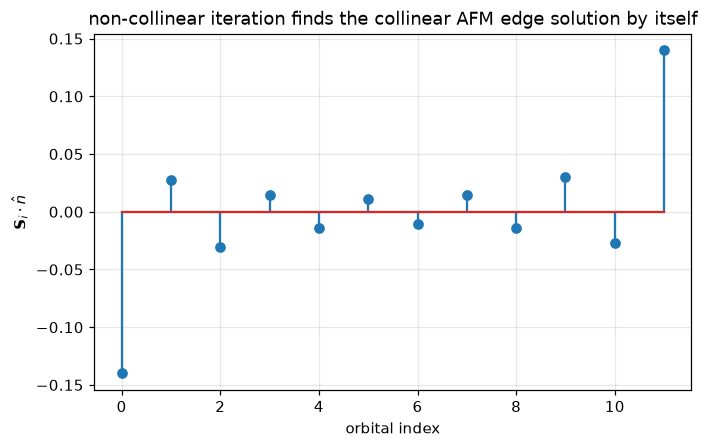

[PASS] IV.3: converged moments are collinear along a common axis — max misalignment = 0.0000
[PASS] IV.3: edge moments antiparallel, |m| matches the collinear value ~0.1–0.2 — edge |m| = 0.280, 0.280


True

In [9]:
def honeycomb_s(t):
    lat = Lattice(lat_vecs=[[1.0, 0.0], [0.5, np.sqrt(3)/2]],
                  orb_vecs=[[1/3, 1/3], [2/3, 2/3]], periodic_dirs=[0, 1])
    m = TBModel(lat, spinful=True)
    m.set_hop(t, 0, 1, [0, 0]); m.set_hop(t, 1, 0, [1, 0]); m.set_hop(t, 1, 0, [0, 1])
    return m

U, NW, NK = 1.2, 6, 24
ribs = honeycomb_s(-1.0).cut_piece(NW, 1, glue_edges=False)
norb = ribs.norb
k_fill = np.array([[k] for k in (np.arange(NK) + 0.5) / NK])

rng_nc = np.random.default_rng(11)
S = 0.05 * (rng_nc.random((norb, 3)) - 0.5)          # random small vector moments
n_avg = np.full(norb, 1.0)                            # one electron per site

for it in range(250):
    m = ribs.copy()
    onsites = [[U * n_avg[i] / 2, -U * S[i, 0], -U * S[i, 1], -U * S[i, 2]]
               for i in range(norb)]
    m.set_onsite(onsites, mode="reset")
    ev, vec = m.solve_ham(k_fill, return_eigvecs=True)
    n_occ = norb                                      # half filling of 2*norb states
    psi = vec[:, :n_occ, :].reshape(NK, n_occ, norb, 2)
    rho = np.einsum("knis,knit->ist", psi, psi.conj()) / NK   # per-site 2x2 density
    n_new = np.real(rho[:, 0, 0] + rho[:, 1, 1])
    S_new = 0.5 * np.stack([2 * np.real(rho[:, 0, 1]),
                            -2 * np.imag(rho[:, 0, 1]),
                            np.real(rho[:, 0, 0] - rho[:, 1, 1])], axis=1)
    dS = np.abs(S_new - S).max()
    S = 0.5 * S + 0.5 * S_new
    n_avg = 0.5 * n_avg + 0.5 * n_new
    if dS < 1e-8:
        break
print(f"converged after {it+1} iterations (ΔS = {dS:.1e})")

S_mag = np.linalg.norm(S, axis=1)
n_hat = S[np.argmax(S_mag)] / S_mag.max()
cosines = (S @ n_hat) / np.where(S_mag > 1e-6, S_mag, 1)

fig, ax = plt.subplots()
ax.stem(np.arange(norb), S @ n_hat)
ax.set_xlabel("orbital index"); ax.set_ylabel(r"$\mathbf{S}_i \cdot \hat n$")
ax.set_title("non-collinear iteration finds the collinear AFM edge solution by itself")
plt.show()
caption("Converged moments of the unconstrained vector mean field, projected on "
        "the common axis the iteration itself selected: starting from randomly "
        "oriented seeds, every site's moment ends parallel or antiparallel to one "
        "spontaneous direction, reproducing the collinear edge-antiferromagnet of "
        "§29. The collinear solution is a true minimum, not an artifact of a "
        "collinear ansatz — and the global spin-rotation freedom (which axis) is "
        "the expected Goldstone degeneracy of the mean field.")

sig = S_mag > 0.01
check("IV.3: converged moments are collinear along a common axis",
      np.all(np.abs(np.abs(cosines[sig]) - 1) < 0.02),
      f"max misalignment = {np.abs(np.abs(cosines[sig]) - 1).max():.4f}")
check("IV.3: edge moments antiparallel, |m| matches the collinear value ~0.1–0.2",
      (S[0] @ n_hat) * (S[-1] @ n_hat) < 0 and 0.05 < 2 * S_mag[[0, -1]].min(),
      f"edge |m| = {2*S_mag[0]:.3f}, {2*S_mag[-1]:.3f}")

<a id="ex-IV-4"></a>

## IV.4 — A self-consistent Kitaev chain

Promote the fixed pairing of §18 to the T = 0 gap equation
$\Delta = \tfrac{g}{N}\sum_k \sin K \,\langle c_{-k}c_k\rangle
        = g\,\Delta\,\tfrac{1}{N}\sum_k \tfrac{2\sin^2 K}{2E_k}$, iterated with PythTB supplying
$E_k$ at every step. On a finite chain the Cooper-log is cut by the level spacing, so a *sharp*
critical coupling emerges: $g_c^{-1} = \tfrac1N\sum_k \sin^2 K/|\xi_k|$, below which the gap
iterates to zero.

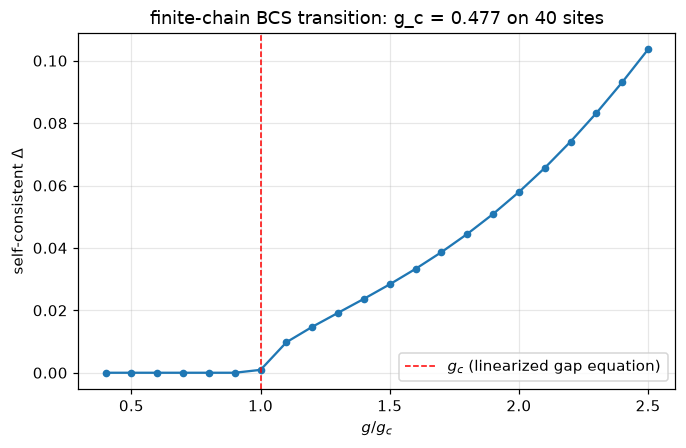

[PASS] IV.4: gap vanishes below g_c and is finite above
[PASS] IV.4: converged Δ satisfies the gap equation 1 = g⟨sin²K/E⟩ — g⟨sin²K/E⟩ = 1.00000000


True

In [10]:
N_site, mu_sc, t_sc = 40, 0.5, 1.0
k_red = (np.arange(N_site) + 0.5) / N_site           # antiperiodic grid avoids xi = 0
K = 2 * np.pi * k_red
xi = -2 * t_sc * np.cos(K) - mu_sc

def gap_iterate(g, D0=0.5, n_iter=500):
    D = D0
    for _ in range(n_iter):
        m = TBModel(Lattice(lat_vecs=[[1.0]], orb_vecs=[[0.0], [0.0]], periodic_dirs=[0]))
        m.set_onsite([-mu_sc, +mu_sc])
        m.set_hop(-t_sc, 0, 0, [1]); m.set_hop(+t_sc, 1, 1, [1])
        m.set_hop(-D, 0, 1, [1]); m.set_hop(+D, 0, 1, [-1], allow_conjugate_pair=True)
        E_k = np.abs(m.solve_ham(np.array([[k] for k in k_red]))).max(axis=1)
        D_new = g * np.mean(2 * D * np.sin(K) ** 2 / (2 * np.clip(E_k, 1e-12, None)))
        if abs(D_new - D) < 1e-12:
            D = D_new; break
        D = D_new
    return D

g_c = 1.0 / np.mean(np.sin(K) ** 2 / np.abs(xi))
g_scan = np.linspace(0.4 * g_c, 2.5 * g_c, 22)
D_scan = np.array([gap_iterate(g) for g in g_scan])

fig, ax = plt.subplots()
ax.plot(g_scan / g_c, D_scan, "o-", ms=4)
ax.axvline(1.0, color="r", ls="--", lw=1, label=r"$g_c$ (linearized gap equation)")
ax.set_xlabel(r"$g / g_c$"); ax.set_ylabel(r"self-consistent $\Delta$")
ax.legend(); ax.set_title(f"finite-chain BCS transition: g_c = {g_c:.3f} on {N_site} sites")
plt.show()
caption("Self-consistent pairing amplitude of the Kitaev chain versus coupling: "
        "Δ iterates to zero below the critical coupling predicted by the "
        "linearized gap equation (red line) and rises continuously above it. On "
        "an infinite chain any g > 0 would pair (the BCS log); the finite k-grid "
        "cuts the log and produces the sharp threshold — a finite-size effect "
        "worth recognizing before calling something a quantum phase transition.")

check("IV.4: gap vanishes below g_c and is finite above",
      np.all(D_scan[g_scan < 0.9 * g_c] < 1e-8)
      and np.all(D_scan[g_scan > 1.1 * g_c] > 1e-3))
# fixed-point consistency at one coupling
g_test = 1.8 * g_c
D_star = gap_iterate(g_test)
E_star = np.sqrt(xi ** 2 + (2 * D_star * np.sin(K)) ** 2)
lhs = g_test * np.mean(2 * np.sin(K) ** 2 / (2 * E_star))
check("IV.4: converged Δ satisfies the gap equation 1 = g⟨sin²K/E⟩",
      np.isclose(lhs, 1.0, atol=1e-6), f"g⟨sin²K/E⟩ = {lhs:.8f}")

In [11]:
# ---- tally for this notebook ---------------------------------------------------
print("=" * 66)
print(f"exercises Parts III–IV — checks passed : {_CHECKS['pass']}")
print(f"exercises Parts III–IV — checks failed : {_CHECKS['fail']}")
print(f"wall time                              : {time.time() - t_chapter_start:.0f} s")
print("=" * 66)
print("Every quantitative claim in this notebook was verified in this run."
      if _CHECKS["fail"] == 0 else "Some checks FAILED — search this notebook for '[FAIL]'.")

exercises Parts III–IV — checks passed : 14
exercises Parts III–IV — checks failed : 0
wall time                              : 62 s
Every quantitative claim in this notebook was verified in this run.
